# More about Correlation: Python Companion

**ENGR 1451/2451 · Exploratory Data Science · w05b**




## 1. Setup

We will use a few small data sets so the Python commands are easy to see.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.precision", 3)

## 2. What changes the correlation?

Start with the small data set from the slides. Calculate $r$ after switching columns, shifting one column, scaling one column, and flipping the sign of one column.


In [2]:
xy = pd.DataFrame({
    "x": [1, 2, 3, 4, 5],
    "y": [2, 3, 1, 5, 6],
})

display(xy)

r_checks = pd.Series({
    "Original": xy["x"].corr(xy["y"]),
    "Switch x and y": xy["y"].corr(xy["x"]),
    "Add 3 to y": xy["x"].corr(xy["y"] + 3),
    "Double x": (2 * xy["x"]).corr(xy["y"]),
    "Multiply y by -1": xy["x"].corr(-xy["y"]),
}, name="Pearson r")

display(r_checks.round(3))

,x,y
0,1,2
1,2,3
2,3,1
3,4,5
4,5,6


Original            0.762
Switch x and y      0.762
Add 3 to y          0.762
Double x            0.762
Multiply y by -1   -0.762
Name: Pearson r, dtype: float64

Adding a constant and multiplying by a positive constant do not change $r$. Multiplying one variable by a negative constant reverses the sign.


## 3. Same $r$, different visual spread

Correlation is based on standardized values. It describes clustering **relative to the spread of the variables**, not in the original units.


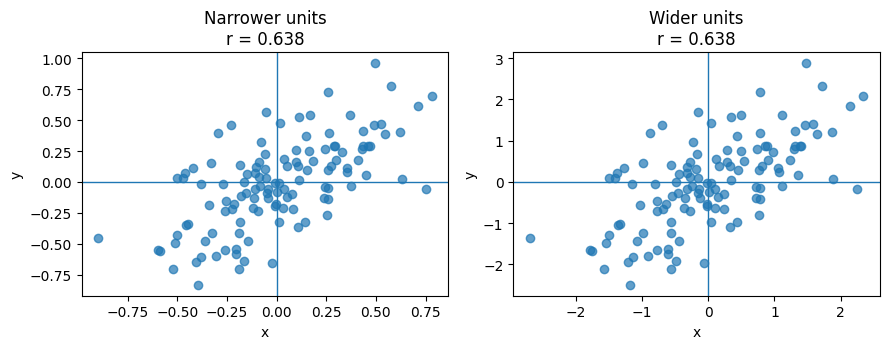

In [3]:
rng = np.random.default_rng(51)
wide = pd.DataFrame(
    rng.multivariate_normal([0, 0], [[1, 0.7], [0.7, 1]], size=120),
    columns=["x", "y"],
)
narrow = wide / 3

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=False, sharey=False)

for ax, data, title in zip(axes, [narrow, wide], ["Narrower units", "Wider units"]):
    ax.scatter(data["x"], data["y"], alpha=0.7)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set(title=f"{title}\nr = {data['x'].corr(data['y']):.3f}", xlabel="x", ylabel="y")

plt.tight_layout()

The two plots use different numerical scales, but the standardized positions of the points are the same, so the correlations match.


## 4. Plot first: curves and outliers

A correlation coefficient summarizes **linear** association. It can miss a curved pattern or be dominated by an unusual point.


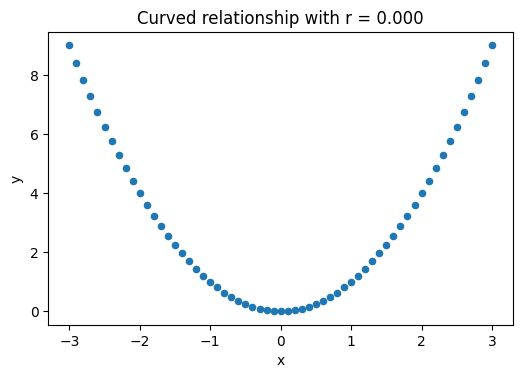

In [4]:
x = np.linspace(-3, 3, 61)
curve = pd.DataFrame({"x": x, "y": x**2})

ax = curve.plot.scatter(x="x", y="y", figsize=(6, 3.8))
ax.set(
    title=f"Curved relationship with r = {curve['x'].corr(curve['y']):.3f}",
    xlabel="x",
    ylabel="y",
)
plt.show()

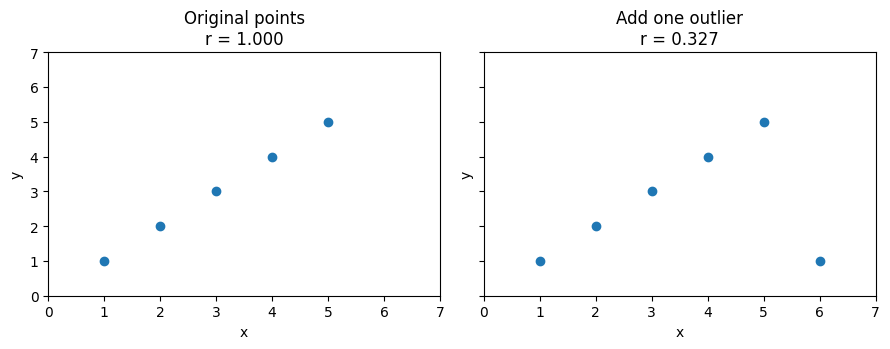

In [5]:
base = pd.DataFrame({"x": [1, 2, 3, 4, 5], "y": [1, 2, 3, 4, 5]})
extra = pd.DataFrame({"x": [6], "y": [1]})
with_outlier = pd.concat([base, extra], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True, sharey=True)

for ax, data, title in zip(axes, [base, with_outlier], ["Original points", "Add one outlier"]):
    ax.scatter(data["x"], data["y"])
    ax.set(
        title=f"{title}\nr = {data['x'].corr(data['y']):.3f}",
        xlabel="x",
        ylabel="y",
        xlim=(0, 7),
        ylim=(0, 7),
    )

plt.tight_layout()

Do not remove unusual points just because they change $r$. First ask whether the point is a data-entry error, a different population, or a real observation that needs explanation.


## 5. Individuals versus group averages

An ecological correlation is calculated from group rates or group averages. That can answer a useful group-level question, but it is not automatically the same as an individual-level relationship.


In [2]:
people = pd.DataFrame({
    "group": ["A"] * 5 + ["B"] * 5 + ["C"] * 5,
    "education": [10, 11, 12, 13, 14, 12, 13, 14, 15, 16, 14, 15, 16, 17, 18],
    "income_k": [48, 52, 50, 55, 51, 61, 66, 63, 68, 65, 73, 77, 75, 80, 76],
})

group_means = (
    people.groupby("group", as_index=False)
    .agg(education=("education", "mean"), income_k=("income_k", "mean"))
)

print(f"Individual-level r: {people['education'].corr(people['income_k']):.3f}")
print(f"Group-average r:   {group_means['education'].corr(group_means['income_k']):.3f}")

display(group_means)

Individual-level r: 0.818
Group-average r:   0.999


,group,education,income_k
0,A,12.0,51.2
1,B,14.0,64.6
2,C,16.0,76.2


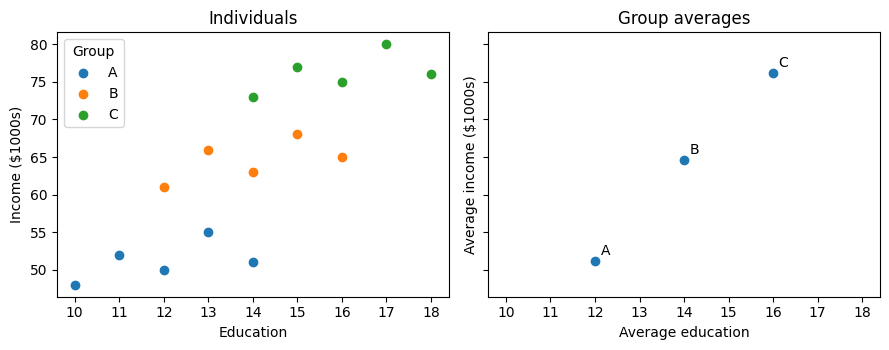

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True, sharey=True)

for group, data in people.groupby("group", sort=True):
    axes[0].scatter(data["education"], data["income_k"], label=group)

axes[0].set(title="Individuals", xlabel="Education", ylabel="Income ($1000s)")
axes[0].legend(title="Group")

axes[1].scatter(group_means["education"], group_means["income_k"])
for _, row in group_means.iterrows():
    axes[1].annotate(row["group"], (row["education"], row["income_k"]), xytext=(4, 4), textcoords="offset points")

axes[1].set(title="Group averages", xlabel="Average education", ylabel="Average income ($1000s)")

plt.tight_layout()

The second plot hides the spread inside each group.


## 7. Your turn

The table below gives per-capita cigarette consumption in several countries in 1930 and lung-cancer death rates for men in 1950.

1. Plot a scatter diagram for these data.
2. Calculate the correlation coefficient.
3. Answer the following questions:
   - **(b)** True or false: the higher cigarette consumption was in 1930 in one of these countries, on the whole the higher the death rate from lung cancer in 1950. Or can this be determined from the data?
   - **(c)** True or false: death rates from lung cancer tend to be higher among those persons who smoke more. Or can this be determined from the data?
4. Identify the unit of analysis. Are the rows people or countries?


In [ ]:
smoking = pd.DataFrame({
    "country": [
        "Australia", "Canada", "Denmark", "Finland", "Great Britain",
        "Iceland", "Netherlands", "Norway", "Sweden", "Switzerland", "U.S.",
    ],
    "cigarettes_1930": [480, 500, 380, 1100, 1100, 230, 490, 250, 300, 510, 1300],
    "deaths_per_million_1950": [180, 150, 170, 350, 460, 60, 240, 90, 110, 250, 200],
})

smoking

In [9]:
# Your code here:
# 1. Create a scatterplot with cigarettes_1930 on the x-axis.
# 2. Calculate Pearson's r.
# 3. Label the axes clearly.



**Your interpretation:**

- Part (b):  
- Part (c):  
- Unit of analysis:  
- One-sentence caution about causation or ecological correlation:  
